In [1]:
import sys
sys.path.append("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/src")

from player_analytics import *

In [2]:
import pandas as pd

In [3]:
match_id = 3869685

events = pd.read_json(
    f"C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/events/{match_id}.json"
)

events.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,duel,interception,dribble,shot,goalkeeper,ball_recovery,foul_committed,substitution,50_50,bad_behaviour
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,2026-06-19 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,2026-06-19 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,2026-06-19 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,2026-06-19 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,2026-06-19 00:00:00.578,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 771, 'name': 'France'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
shots = events[
    events['type'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ) == 'Shot'
]

shots[['player', 'location', 'shot']].head()

,player,location,shot
191,"{'id': 27886, 'name': 'Alexis Mac Allister'}","[92.4, 30.0]","{'statsbomb_xg': 0.024542088, 'end_location': ..."
339,"{'id': 7797, 'name': 'Rodrigo Javier De Paul'}","[99.2, 47.9]","{'statsbomb_xg': 0.062813334, 'end_location': ..."
601,"{'id': 2995, 'name': 'Ángel Fabián Di María He...","[103.1, 34.6]","{'statsbomb_xg': 0.106800534, 'end_location': ..."
770,"{'id': 5503, 'name': 'Lionel Andrés Messi Cucc...","[108.0, 40.0]","{'statsbomb_xg': 0.7835000000000001, 'end_loca..."
978,"{'id': 27886, 'name': 'Alexis Mac Allister'}","[94.3, 23.5]","{'statsbomb_xg': 0.010577817000000002, 'end_lo..."


In [5]:
shots.iloc[0]['shot']

{'statsbomb_xg': 0.024542088,
 'end_location': [117.3, 38.3, 0.8],
 'key_pass_id': 'b8d55d4b-37dc-4491-ad9c-baa235eec9df',
 'technique': {'id': 93, 'name': 'Normal'},
 'body_part': {'id': 40, 'name': 'Right Foot'},
 'type': {'id': 87, 'name': 'Open Play'},
 'outcome': {'id': 100, 'name': 'Saved'},
 'freeze_frame': [{'location': [101.0, 48.0],
   'player': {'id': 6704, 'name': 'Theo Bernard François Hernández'},
   'position': {'id': 6, 'name': 'Left Back'},
   'teammate': False},
  {'location': [102.8, 36.1],
   'player': {'id': 8519, 'name': 'Dayotchanculle Upamecano'},
   'position': {'id': 5, 'name': 'Left Center Back'},
   'teammate': False},
  {'location': [103.0, 26.7],
   'player': {'id': 5485, 'name': 'Raphaël Varane'},
   'position': {'id': 3, 'name': 'Right Center Back'},
   'teammate': False},
  {'location': [101.9, 21.4],
   'player': {'id': 4445, 'name': 'Jules Koundé'},
   'position': {'id': 2, 'name': 'Right Back'},
   'teammate': False},
  {'location': [98.6, 27.9],
   

In [6]:
import pandas as pd

def get_player_shots(events, player_name):

    shots = events[
        events['type'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == 'Shot'
    ]

    player_shots = shots[
        shots['player'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == player_name
    ]

    shot_data = []

    for _, shot in player_shots.iterrows():

        shot_info = shot['shot']

        shot_data.append({
            'x': shot['location'][0],
            'y': shot['location'][1],
            'xG': shot_info.get('statsbomb_xg', 0),
            'Outcome': shot_info['outcome']['name']
        })

    return pd.DataFrame(shot_data)

In [7]:
messi_shots_df = get_player_shots(
    events,
    'Lionel Andrés Messi Cuccittini'
)

messi_shots_df

,x,y,xG,Outcome
0,108.0,40.0,0.783500,Goal
1,109.7,46.0,0.115560,Off T
2,96.2,40.9,0.043032,Saved
3,103.6,55.8,0.024785,Saved
4,116.6,43.0,0.488404,Goal
5,108.1,40.1,0.783500,Goal


In [8]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def plot_player_shotmap(events, player_name):

    shots_df = get_player_shots(events, player_name)

    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color='#1B4332',
        line_color='white',
        linewidth=2,
        half=True
    )

    fig, ax = pitch.draw(figsize=(12, 8))

    goals = shots_df[
        shots_df['Outcome'] == 'Goal'
    ]

    non_goals = shots_df[
        shots_df['Outcome'] != 'Goal'
    ]

    # Non-goals
    pitch.scatter(
        non_goals['x'],
        non_goals['y'],
        s=non_goals['xG'] * 3000,
        color='white',
        edgecolors='black',
        alpha=0.7,
        ax=ax
    )

    # Goals
    pitch.scatter(
        goals['x'],
        goals['y'],
        s=goals['xG'] * 3000,
        color='lime',
        edgecolors='black',
        alpha=0.9,
        ax=ax
    )

    fig.set_facecolor('#1B4332')

    ax.set_title(
        f"{player_name} Shot Map",
        color='white',
        fontsize=18
    )

    return fig

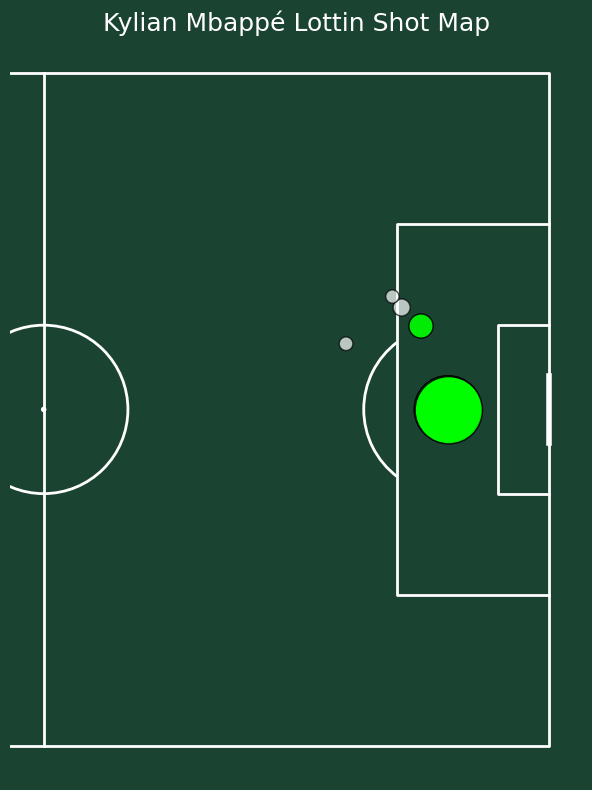

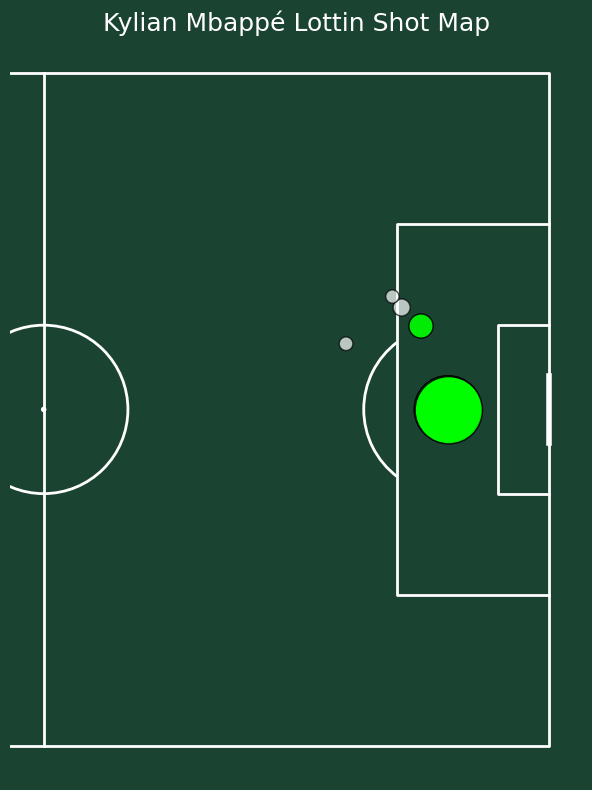

In [9]:
plot_player_shotmap(
    events,
    'Kylian Mbappé Lottin'
)